# Plot mean / median of all connection profiles for velocity implementation

In [1]:
## functions

# ===== REUSABLE FUNCTIONS FOR COMPLEX SIMULATIONS =====

def circular_gaussian(x, mu, sigma, A):
    
    # Handle periodic boundary conditions
    diff = np.array([(xi - mu + NBINS/2) % NBINS - NBINS/2 for xi in x])
    return A * np.exp(-0.5 * (diff / sigma)**2)

def fit_circular_gaussian(firing_rates):
    positions = np.arange(NBINS)
    
    # Skip if no activity
    if np.sum(firing_rates) == 0:
        return np.nan, np.nan, np.nan  # mu, sigma, A
    
    # Initial guess: peak at maximum firing rate position
    max_pos = np.argmax(firing_rates)
    initial_A = np.max(firing_rates)
    initial_sigma = 1.0
    
    def objective(params):
        mu, sigma, A = params
        if sigma <= 0 or A < 0:
            return 1e10
        predicted = circular_gaussian(positions, mu, sigma, A)
        return np.sum((firing_rates - predicted)**2)
    
    # Try optimization with different initial conditions
    best_result = None
    best_error = np.inf
    
    for init_mu in [max_pos, (max_pos + 1) % NBINS, (max_pos - 1) % NBINS]:
        try:
            result = minimize(objective, [init_mu, initial_sigma, initial_A],
                            method='L-BFGS-B',
                            bounds=[(0, NBINS-1), (0.1, NBINS/2), (0, None)])
            if result.success and result.fun < best_error:
                best_result = result
                best_error = result.fun
                
        except:
            continue
    
    if best_result is not None:
        mu, sigma, A = best_result.x
        # Normalize mu to [0, NBINS) range
        mu = mu % NBINS
        return mu, sigma, A
    else:
        return np.nan, np.nan, np.nan


def run_offline_simulation(time_phase1, time_phase2, time_phase3, spike_pop_id):
    """
    Run offline simulation with three phases and velocity modulation.
    
    Parameters:
    - time_phase1: Duration of initial phase (seconds)
    - time_phase2: Duration of velocity phase (seconds) 
    - time_phase3: Duration of no-velocity phase (seconds)
    - spike_pop_id: Population ID to stimulate (0-9)
    
    Returns:
    - all_events: List of collected spike events
    """
    print(f"\nStarting offline simulation: Pop {spike_pop_id}, phases: {time_phase1}s, {time_phase2}s, {time_phase3}s")
    
    # Initialize storage for all events
    all_events = []
    simulation_phases = []
    
    # Clear any existing events
    eventsBuffer.clear()
    sink_node.get_events()
    
    # === PHASE 1: Initial stimulation ===
    print(f"Phase 1: Stimulating population {spike_pop_id} for {time_phase1} seconds...")
    
    # Set FPGA to stimulate specified population
    spike_ids[:] = spike_pop_id + spikegen_offset
    ut.set_fpga_spike_gen(fpga_spike_gen,
                          all_spike_times, spike_ids,
                          target_chips=[0]*len(spike_ids),
                          isi_base=900, repeat_mode=False)
    
    # Start simulation
    api.reset_timestamp()
    fpga_spike_gen.start()
    phase1_start = time.time()
    
    while time.time() - phase1_start < time_phase1:
        new_events = sink_node.get_events()
        for event in new_events:
            all_events.append(event)
            simulation_phases.append("Phase 1: Initial")
        time.sleep(0.01)
    
    fpga_spike_gen.stop()
    print(f"Phase 1 complete. Collected {len([p for p in simulation_phases if p == 'Phase 1: Initial'])} events.")
    
    # === PHASE 2: Add velocity connections ===
    print(f"Phase 2: Adding velocity connections and running for {time_phase2} seconds...")
    
    pre_list = []
    post_list = []
    
    if conn == 1:
        for i, pop_i in enumerate(ring_pops):
            for p, pre in enumerate(pop_i):
                j = (i + 1) % NBINS
                post = ring_pops[j][p]
                net_gen.add_connection(pre, post, dyn1.Dynapse1SynType.NMDA)

    if conn == 2:
        for i, pop_i in enumerate(ring_pops):
            for p, pre in enumerate(pop_i):
                j = (i + 1) % NBINS
                post1 = ring_pops[j][p]
                post2 = ring_pops[j][(p+1)%4]
                net_gen.add_connection(pre, post1, dyn1.Dynapse1SynType.NMDA)   
                net_gen.add_connection(pre, post2, dyn1.Dynapse1SynType.NMDA)   

    if conn == 3:
        for i, pop_i in enumerate(ring_pops):
            print("i", i)
            for p, pre in enumerate(pop_i):
                j = (i + 1) % NBINS
                post1 = ring_pops[j][p]
                post2 = ring_pops[j][(p+1)%4]
                post3 = ring_pops[j][(p+2)%4]
                net_gen.add_connection(pre, post1, dyn1.Dynapse1SynType.NMDA)   
                net_gen.add_connection(pre, post2, dyn1.Dynapse1SynType.NMDA)   
                net_gen.add_connection(pre, post3, dyn1.Dynapse1SynType.NMDA)   
    
    if conn == 4:
    
        # Add velocity connections
        for i, pop_i in enumerate(ring_pops):
            for pre in pop_i:
                j = (i + 1) % NBINS
                for post in ring_pops[j]:
                    #if pre is not post and np.random.rand() < p_vel:
                    #if np.random.rand() < p_vel:
                    net_gen.add_connection(pre, post, dyn1.Dynapse1SynType.NMDA)
                        #print("pre vel neuron", pre)
                        #print("post vel neuron", post)
                    pre_list.append(pre)
                    post_list.append(post)
    
    if conn == 5:
        for i, pop_i in enumerate(ring_pops):
            for pre in pop_i:
                j = (i + 1) % NBINS
                for post in ring_pops[j]:
                    #if pre is not post and np.random.rand() < p_vel:
                    #if np.random.rand() < p_vel:
                    net_gen.add_connection(pre, post, dyn1.Dynapse1SynType.NMDA)
                        #print("pre vel neuron", pre)
                        #print("post vel neuron", post)
                    pre_list.append(pre)
                    post_list.append(post)        
        for i, pop_i in enumerate(ring_pops):
            for p, pre in enumerate(pop_i):
                j = (i + 1) % NBINS
                post = ring_pops[j][p]
                net_gen.add_connection(pre, post, dyn1.Dynapse1SynType.NMDA)
                
    if conn == 6:     
        for i, pop_i in enumerate(ring_pops):
            for pre in pop_i:
                j = (i + 1) % NBINS
                for post in ring_pops[j]:
                    #if pre is not post and np.random.rand() < p_vel:
                    #if np.random.rand() < p_vel:
                    net_gen.add_connection(pre, post, dyn1.Dynapse1SynType.NMDA)
                        #print("pre vel neuron", pre)
                        #print("post vel neuron", post)
                    pre_list.append(pre)
                    post_list.append(post)   
                    
        for i, pop_i in enumerate(ring_pops):
            for p, pre in enumerate(pop_i):
                j = (i + 1) % NBINS
                post1 = ring_pops[j][p]
                post2 = ring_pops[j][(p+1)%4]
                net_gen.add_connection(pre, post1, dyn1.Dynapse1SynType.NMDA)   
                net_gen.add_connection(pre, post2, dyn1.Dynapse1SynType.NMDA)  
                
                
    if conn == 7:
        for i, pop_i in enumerate(ring_pops):
            for pre in pop_i:
                j = (i + 1) % NBINS
                for post in ring_pops[j]:
                    #if pre is not post and np.random.rand() < p_vel:
                    #if np.random.rand() < p_vel:
                    net_gen.add_connection(pre, post, dyn1.Dynapse1SynType.NMDA)
                        #print("pre vel neuron", pre)
                        #print("post vel neuron", post)
                    pre_list.append(pre)
                    post_list.append(post)
        for i, pop_i in enumerate(ring_pops):
            print("i", i)
            for p, pre in enumerate(pop_i):
                j = (i + 1) % NBINS
                post1 = ring_pops[j][p]
                post2 = ring_pops[j][(p+1)%4]
                post3 = ring_pops[j][(p+2)%4]
                net_gen.add_connection(pre, post1, dyn1.Dynapse1SynType.NMDA)   
                net_gen.add_connection(pre, post2, dyn1.Dynapse1SynType.NMDA)   
                net_gen.add_connection(pre, post3, dyn1.Dynapse1SynType.NMDA)   

    if conn == 8:
        for i, pop_i in enumerate(ring_pops):
            for pre in pop_i:
                j = (i + 1) % NBINS
                for post in ring_pops[j]:
                    #if pre is not post and np.random.rand() < p_vel:
                    #if np.random.rand() < p_vel:
                    net_gen.add_connection(pre, post, dyn1.Dynapse1SynType.NMDA)
                    net_gen.add_connection(pre, post, dyn1.Dynapse1SynType.NMDA)
                        #print("pre vel neuron", pre)
                        #print("post vel neuron", post)
                    pre_list.append(pre)
                    post_list.append(post)
        
        
    # Apply new configuration
    config = net_gen.make_dynapse1_configuration()
    model.apply_configuration(config)
    print("Velocity connections added.")
    
    # Continue stimulation
    phase2_start = time.time()
    
    while time.time() - phase2_start < time_phase2:
        new_events = sink_node.get_events()
        for event in new_events:
            all_events.append(event)
            simulation_phases.append("Phase 2: Velocity")
        time.sleep(0.01)
    
    print(f"Phase 2 complete. Collected {len([p for p in simulation_phases if p == 'Phase 2: Velocity'])} events.")
    
    # === PHASE 3: Remove velocity connections ===
    print(f"Phase 3: Removing velocity connections and running for {time_phase3} seconds...")

    if conn == 1:
        for i, pop_i in enumerate(ring_pops):
            for p, pre in enumerate(pop_i):
                j = (i + 1) % NBINS
                post = ring_pops[j][p]
                net_gen.remove_connection(pre, post, dyn1.Dynapse1SynType.NMDA)

    if conn == 2:
        for i, pop_i in enumerate(ring_pops):
            for p, pre in enumerate(pop_i):
                j = (i + 1) % NBINS
                post1 = ring_pops[j][p]
                post2 = ring_pops[j][(p+1)%4]
                net_gen.remove_connection(pre, post1, dyn1.Dynapse1SynType.NMDA)   
                net_gen.remove_connection(pre, post2, dyn1.Dynapse1SynType.NMDA)   
                
    if conn == 3:
        for i, pop_i in enumerate(ring_pops):
            for p, pre in enumerate(pop_i):
                j = (i + 1) % NBINS
                post1 = ring_pops[j][p]
                post2 = ring_pops[j][(p+1)%4]
                post3 = ring_pops[j][(p+2)%4]
                net_gen.remove_connection(pre, post1, dyn1.Dynapse1SynType.NMDA)   
                net_gen.remove_connection(pre, post2, dyn1.Dynapse1SynType.NMDA)   
                net_gen.remove_connection(pre, post3, dyn1.Dynapse1SynType.NMDA)   
    
    if conn == 4: 
        for i, pop_i in enumerate(ring_pops):
            for pre in pop_i:
                j = (i + 1) % NBINS
                for post in ring_pops[j]:
                    net_gen.remove_connection(pre, post, dyn1.Dynapse1SynType.NMDA)

    if conn == 5:
        for i, pop_i in enumerate(ring_pops):
            for pre in pop_i:
                j = (i + 1) % NBINS
                for post in ring_pops[j]:
                    #if pre is not post and np.random.rand() < p_vel:
                    #if np.random.rand() < p_vel:
                    net_gen.remove_connection(pre, post, dyn1.Dynapse1SynType.NMDA)
                        #print("pre vel neuron", pre)
                        #print("post vel neuron", post)
                    pre_list.append(pre)
                    post_list.append(post)        
        for i, pop_i in enumerate(ring_pops):
            for p, pre in enumerate(pop_i):
                j = (i + 1) % NBINS
                post = ring_pops[j][p]
                net_gen.remove_connection(pre, post, dyn1.Dynapse1SynType.NMDA)
                
    if conn == 6:     
        for i, pop_i in enumerate(ring_pops):
            for pre in pop_i:
                j = (i + 1) % NBINS
                for post in ring_pops[j]:
                    #if pre is not post and np.random.rand() < p_vel:
                    #if np.random.rand() < p_vel:
                    net_gen.remove_connection(pre, post, dyn1.Dynapse1SynType.NMDA)
                        #print("pre vel neuron", pre)
                        #print("post vel neuron", post)
                    pre_list.append(pre)
                    post_list.append(post)   
                    
        for i, pop_i in enumerate(ring_pops):
            for p, pre in enumerate(pop_i):
                j = (i + 1) % NBINS
                post1 = ring_pops[j][p]
                post2 = ring_pops[j][(p+1)%4]
                net_gen.remove_connection(pre, post1, dyn1.Dynapse1SynType.NMDA)   
                net_gen.remove_connection(pre, post2, dyn1.Dynapse1SynType.NMDA)  

    if conn == 7:
        for i, pop_i in enumerate(ring_pops):
            for pre in pop_i:
                j = (i + 1) % NBINS
                for post in ring_pops[j]:
                    #if pre is not post and np.random.rand() < p_vel:
                    #if np.random.rand() < p_vel:
                    net_gen.remove_connection(pre, post, dyn1.Dynapse1SynType.NMDA)
                        #print("pre vel neuron", pre)
                        #print("post vel neuron", post)
                    pre_list.append(pre)
                    post_list.append(post)
        for i, pop_i in enumerate(ring_pops):
            print("i", i)
            for p, pre in enumerate(pop_i):
                j = (i + 1) % NBINS
                post1 = ring_pops[j][p]
                post2 = ring_pops[j][(p+1)%4]
                post3 = ring_pops[j][(p+2)%4]
                net_gen.remove_connection(pre, post1, dyn1.Dynapse1SynType.NMDA)   
                net_gen.remove_connection(pre, post2, dyn1.Dynapse1SynType.NMDA)   
                net_gen.remove_connection(pre, post3, dyn1.Dynapse1SynType.NMDA)   
                
    if conn == 8:
        for i, pop_i in enumerate(ring_pops):
            for pre in pop_i:
                j = (i + 1) % NBINS
                for post in ring_pops[j]:
                    #if pre is not post and np.random.rand() < p_vel:
                    #if np.random.rand() < p_vel:
                    net_gen.remove_connection(pre, post, dyn1.Dynapse1SynType.NMDA)
                    net_gen.remove_connection(pre, post, dyn1.Dynapse1SynType.NMDA)
                        #print("pre vel neuron", pre)
                        #print("post vel neuron", post)
                    pre_list.append(pre)
                    post_list.append(post)
               
    """for i in range(len(pre_list)):
        net_gen.remove_connection(pre_list[i], post_list[i], dyn1.Dynapse1SynType.NMDA)"""
    

    # Apply new configuration
    config = net_gen.make_dynapse1_configuration()
    model.apply_configuration(config)
    print("Velocity connections removed.")
    
    # Continue stimulation
    phase3_start = time.time()
    
    while time.time() - phase3_start < time_phase3:
        new_events = sink_node.get_events()
        for event in new_events:
            all_events.append(event)
            simulation_phases.append("Phase 3: No velocity")
        time.sleep(0.01)
    
    print(f"Phase 3 complete. Collected {len([p for p in simulation_phases if p == 'Phase 3: No velocity'])} events.")
    
    # Final event collection
    final_events = sink_node.get_events()
    for event in final_events:
        all_events.append(event)
        simulation_phases.append("Phase 3: No velocity")
        
    ut.set_neuron_tau1(model, 0, 1, (7, 255))
    ut.set_neuron_tau1(model, 0, 2, (7, 255))

    time.sleep(0.5)

    ut.set_neuron_tau1(model, 0, 1, (4, 50))
    ut.set_neuron_tau1(model, 0, 2, (4, 200))# save the drift for this cycle
    
    time.sleep(0.5)
    
    print(f"Simulation complete! Total events collected: {len(all_events)}")
    return all_events


def create_raster_plot(all_events, time_phase1, time_phase2, time_phase3, spike_pop_id):
    """
    Create raster plot from simulation events.
    
    Parameters:
    - all_events: List of spike events from simulation
    - time_phase1, time_phase2, time_phase3: Phase durations for marking transitions
    - spike_pop_id: Population that was stimulated (for title)
    
    Returns:
    - None (displays plot)
    """
    print("Creating raster plot...")
    
    if len(all_events) == 0:
        print("No events to plot!")
        return
    
    # Extract event data and normalize timestamps to start from 0
    raw_timestamps = [e.timestamp * 1e-6 for e in all_events]  # Convert to seconds
    start_time = min(raw_timestamps)  # Get the first timestamp
    event_times = [t - start_time for t in raw_timestamps]  # Normalize to start from 0
    event_neuron_ids = [e.neuron_id for e in all_events]
    
    # Create neuron ID to population mapping for coloring
    nid_to_pop = {}
    for pop_idx, pop in enumerate(ring_pops):
        for n in pop:
            nid_to_pop[n.neuron_id] = pop_idx
    
    # Give inhibitory population its own index
    INH_IDX = NBINS
    for n in pop_inhibitory:
        nid_to_pop[n.neuron_id] = INH_IDX
    
    # Map colors
    import matplotlib.cm as cm
    pop_colors = cm.get_cmap('tab10', NBINS+1)
    evt_colors = []
    for nid in event_neuron_ids:
        pop_idx = nid_to_pop.get(nid, None)
        if pop_idx is None or pop_idx == INH_IDX:
            evt_colors.append('lightgrey')
        else:
            evt_colors.append(pop_colors(pop_idx))
    
    # Create the plot
    plt.figure(figsize=(15, 8))
    plt.scatter(event_times, event_neuron_ids, s=3, c=evt_colors, alpha=0.7)
    
    # Add vertical lines to mark phase transitions
    plt.axvline(time_phase1, color='red', linestyle='--', linewidth=2, alpha=0.8, label='Velocity ON')
    plt.axvline(time_phase1 + time_phase2, color='blue', linestyle='--', linewidth=2, alpha=0.8, label='Velocity OFF') 
    
    # Add population labels and set y-axis limits
    y_max = max(event_neuron_ids) if event_neuron_ids else 100
    plt.ylim(0, y_max + 5)
    
    plt.xlabel('Time (s)', fontsize=12)
    plt.ylabel('Neuron ID', fontsize=12)
    plt.title(f'Offline Simulation: Population {spike_pop_id} Stimulation with Velocity Modulation\n' + 
              f'Phase 1 (0-{time_phase1}s): Initial | Phase 2 ({time_phase1}-{time_phase1+time_phase2}s): +Velocity | Phase 3 ({time_phase1+time_phase2}-{time_phase1+time_phase2+time_phase3}s): -Velocity', 
              fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    #plt.show()


def analyze_peak_tracking(all_events, time_phase1, time_phase2, time_phase3, timestep=0.5):
    """
    Perform peak tracking analysis on simulation events.
    
    Parameters:
    - all_events: List of spike events from simulation
    - time_phase1, time_phase2, time_phase3: Phase durations for marking transitions
    - timestep: Time window size for analysis (seconds)
    
    Returns:
    - peak_positions_degrees: Array of peak positions in degrees
    - peak_times: Array of time points for each peak
    """
    print("Starting peak tracking analysis...")
    
    #print('events : ', all_events)
    if len(all_events) == 0:
        print("No events to analyze!")
        return np.array([]), np.array([])
    
    # Extract and normalize event data
    raw_timestamps = [e.timestamp * 1e-6 for e in all_events]
    start_time = min(raw_timestamps)
    event_times = [t - start_time for t in raw_timestamps]
    event_neuron_ids = [e.neuron_id for e in all_events]
    
    # Create neuron ID to population mapping
    nid_to_pop = {}
    for pop_idx, pop in enumerate(ring_pops):
        for n in pop:
            nid_to_pop[n.neuron_id] = pop_idx
    
    # Analysis parameters
    total_duration = time_phase1 + time_phase2 + time_phase3
    time_bins = np.arange(0, total_duration + timestep, timestep)
    
    # Storage for results
    peak_positions = []
    peak_times = []
    all_firing_rates = []
    fit_quality = []
    
    print(f"Analyzing {len(time_bins)-1} time windows...")
    
    for i in range(len(time_bins) - 1):
        t_start = time_bins[i]
        t_end = time_bins[i + 1]
        
        # Find events in this time window
        window_events = []
        for j, event_time in enumerate(event_times):
            if t_start <= event_time < t_end:
                window_events.append((event_time, event_neuron_ids[j]))
        
        # Calculate firing rates for each population
        firing_rates = np.zeros(NBINS)
        for event_time, neuron_id in window_events:
            if neuron_id in nid_to_pop and nid_to_pop[neuron_id] < NBINS:  # Exclude inhibitory
                pop_idx = nid_to_pop[neuron_id]
                firing_rates[pop_idx] += 1
        
        # Convert to Hz (events per second)
        firing_rates = firing_rates / timestep
        all_firing_rates.append(firing_rates.copy())
        
        #print('firing_rates : ', firing_rates/timestep)
        
        # Fit circular Gaussian
        mu, sigma, A = fit_circular_gaussian(firing_rates)
        
        print("mu ", mu)
        
        
        peak_positions.append(mu)
        peak_times.append(t_start + timestep/2)  # Center of time window
            
        
    
    peak_positions = np.array(peak_positions)
    peak_times = np.array(peak_times)
    fit_quality = np.array(fit_quality)
    
    # Convert peak positions to degrees (360° / 10 bins = 36° per bin)
    peak_positions_degrees = peak_positions * 360.0 / NBINS
    
    print(f"Successfully tracked {len(peak_positions)} peaks out of {len(time_bins)-1} time windows")
    
    return peak_positions_degrees, peak_times


def plot_peak_tracking(peak_positions_degrees, peak_times, time_phase1, time_phase2, time_phase3):
    """
    Create peak tracking plot from analysis results.
    
    Parameters:
    - peak_positions_degrees: Array of peak positions in degrees
    - peak_times: Array of time points for each peak
    - time_phase1, time_phase2, time_phase3: Phase durations for marking transitions
    
    Returns:
    - None (displays plot)
    """
    if len(peak_positions_degrees) == 0:
        print("No peak data to plot!")
        return
    
    # Create peak tracking plot
    plt.figure(figsize=(12, 6))
    plt.plot(peak_times, peak_positions_degrees, 'ro', markersize=2, alpha=0.8, label='Peak Position')
    
    plt.axvline(time_phase1, color='red', linestyle='--', linewidth=2, alpha=0.8, label='Velocity ON')
    plt.axvline(time_phase1 + time_phase2, color='blue', linestyle='--', linewidth=2, alpha=0.8, label='Velocity OFF')
    
    plt.xlabel('Time (s)', fontsize=12)
    plt.ylabel('Peak Position (degrees)', fontsize=12)
    plt.title('Ring Attractor Peak Position Over Time\n(Population Activity Center Tracking)', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)
    
    plt.ylim(0, 360)
    plt.yticks(np.arange(0, 361, 45), [f'{int(deg)}°' for deg in np.arange(0, 361, 45)])
    
    for deg in np.arange(0, 361, 90):
        plt.axhline(deg, color='gray', linestyle=':', alpha=0.2, linewidth=0.8)
    
    plt.tight_layout()
    plt.show()


# ===== EXAMPLE USAGE =====
print("Functions created successfully!")
print("\nExample usage:")
print("# Run simulation")
print("events = run_offline_simulation(2.0, 7.0, 3.0, 5)")
print("\n# Create raster plot")
print("create_raster_plot(events, 2.0, 7.0, 3.0, 5)")
print("\n# Analyze peak tracking")
print("peak_degrees, peak_times = analyze_peak_tracking(events, 2.0, 7.0, 3.0)")
print("\n# Plot peak tracking results")
print("plot_peak_tracking(peak_degrees, peak_times, 2.0, 7.0, 3.0)")

Functions created successfully!

Example usage:
# Run simulation
events = run_offline_simulation(2.0, 7.0, 3.0, 5)

# Create raster plot
create_raster_plot(events, 2.0, 7.0, 3.0, 5)

# Analyze peak tracking
peak_degrees, peak_times = analyze_peak_tracking(events, 2.0, 7.0, 3.0)

# Plot peak tracking results
plot_peak_tracking(peak_degrees, peak_times, 2.0, 7.0, 3.0)


In [34]:
timestep = 0.5
t1 = 2
t2 = 7
t3 = 3

Found 7 files: ['/Users/flaviadavidhi/Documents/PhD/JointAttractorNets/peak_population_dic_velocity_connection_one_connection_per_pop.npy', '/Users/flaviadavidhi/Documents/PhD/JointAttractorNets/peak_population_dic_velocity_connection_four_connections_per_post_neur.npy', '/Users/flaviadavidhi/Documents/PhD/JointAttractorNets/peak_population_dic_velocity_connection_five_connections_per_pop.npy', '/Users/flaviadavidhi/Documents/PhD/JointAttractorNets/peak_population_dic_velocity_connection_six_connections_per_pop.npy', '/Users/flaviadavidhi/Documents/PhD/JointAttractorNets/peak_population_dic_velocity_connection_three_connections_per_pop.npy', '/Users/flaviadavidhi/Documents/PhD/JointAttractorNets/peak_population_dic_velocity_connection_two_connections_per_pop.npy', '/Users/flaviadavidhi/Documents/PhD/JointAttractorNets/peak_population_dic_velocity_connection_seven_connections_per_pop.npy']


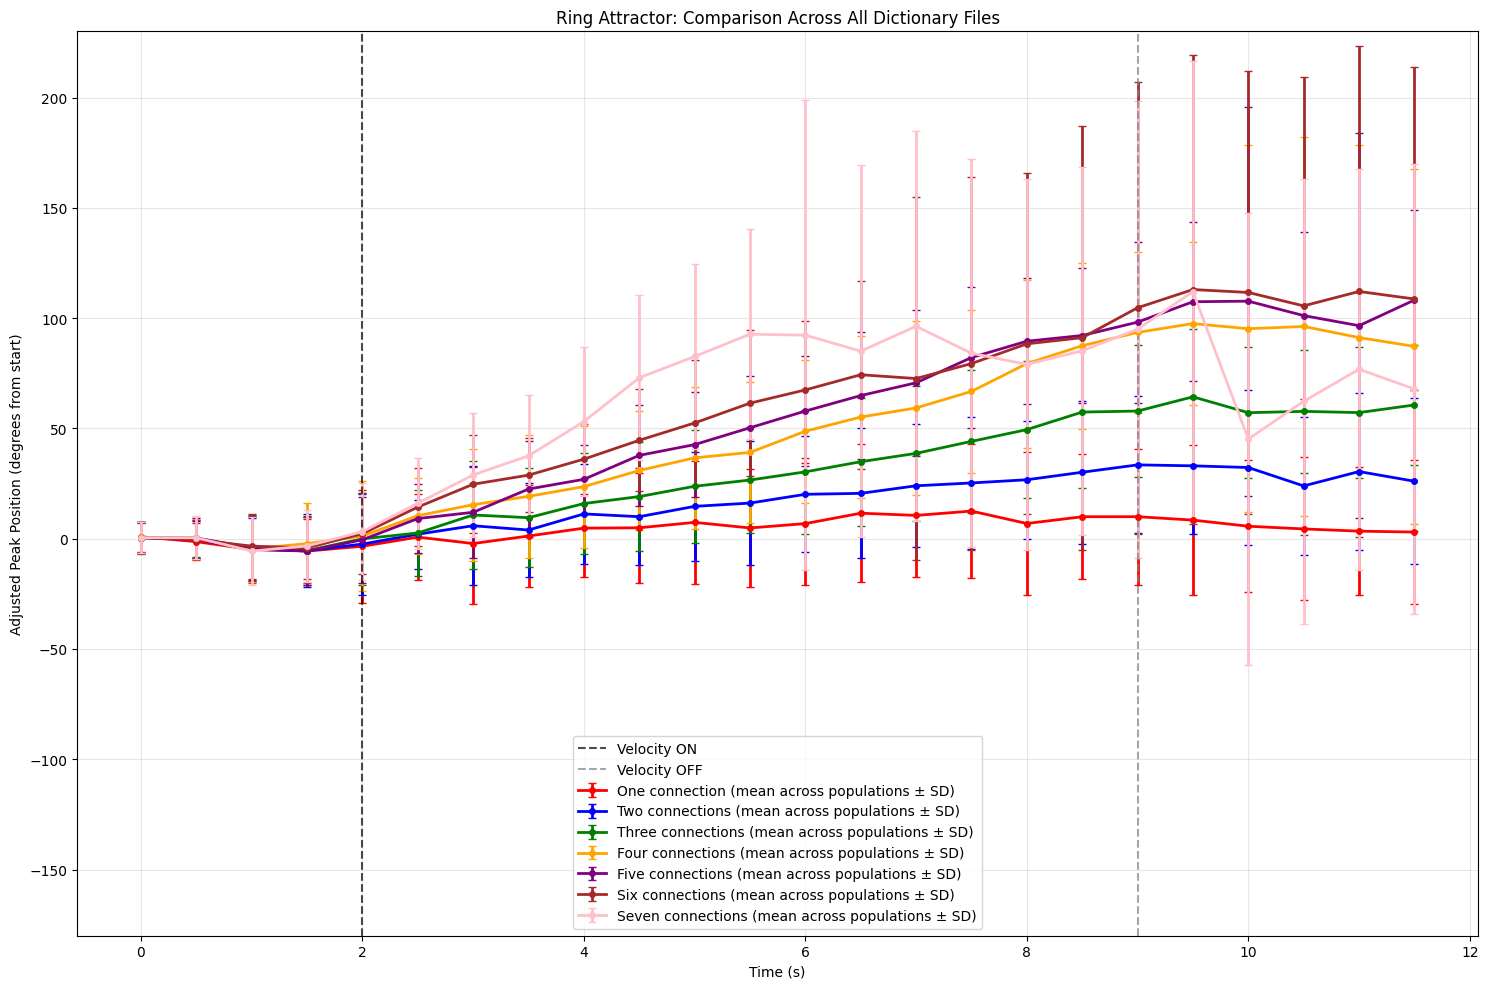

peak_population_dic_velocity_connection_one_connection_per_pop: Mean drift = 4.2°, Mean variability = 25.4°
peak_population_dic_velocity_connection_two_connections_per_pop: Mean drift = 15.7°, Mean variability = 25.2°
peak_population_dic_velocity_connection_three_connections_per_pop: Mean drift = 29.5°, Mean variability = 24.6°
peak_population_dic_velocity_connection_four_connections_per_post_neur: Mean drift = 47.0°, Mean variability = 37.3°
peak_population_dic_velocity_connection_five_connections_per_pop: Mean drift = 52.8°, Mean variability = 29.8°
peak_population_dic_velocity_connection_six_connections_per_pop: Mean drift = 57.7°, Mean variability = 52.7°
peak_population_dic_velocity_connection_seven_connections_per_pop: Mean drift = 56.7°, Mean variability = 60.3°


In [39]:

import os
import numpy as np
import matplotlib.pyplot as plt
from glob import glob

# Find all .npy files containing 'dic' in the filename
npy_files = glob("/Users/flaviadavidhi/Documents/PhD/JointAttractorNets/*dic*.npy")  # or use full path: glob("/path/to/folder/*dic*.npy")
print(f"Found {len(npy_files)} files: {npy_files}")

# Sort files to match with legend labels
def get_number_from_filename(filename):
    if 'one' in filename.lower(): return 1
    elif 'two' in filename.lower(): return 2
    elif 'three' in filename.lower(): return 3
    elif 'four' in filename.lower(): return 4
    elif 'five' in filename.lower(): return 5
    elif 'six' in filename.lower(): return 6
    elif 'seven' in filename.lower(): return 6
    else: return 999  # files without number words go last

npy_files = sorted(npy_files, key=get_number_from_filename)
legend_labels = ["One connection", "Two connections", "Three connections", "Four connections", 
                 "Five connections", "Six connections", "Seven connections"]


# Load all dictionaries and analyze
results = {}
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']

for i, file_path in enumerate(npy_files):
   # Load the dictionary
   peak_dict = np.load(file_path, allow_pickle=True).item()
   file_name = os.path.basename(file_path).replace('.npy', '')
   
   # Your original analysis code for each dictionary
   initial_degrees = {pop: pop * 36 for pop in range(10)}
   adjusted_means = {}
   
   for pop in peak_dict:
       if len(peak_dict[pop]) > 0:
           mean_pos = peak_dict[pop][0]
           initial_deg = initial_degrees[pop]
           diff = mean_pos - initial_deg
           diff = ((diff + 180) % 360) - 180
           adjusted = diff
           adjusted_means[pop] = adjusted
   
   if len(adjusted_means) > 0:
       all_adjusted = np.array(list(adjusted_means.values()))
       all_adjusted_rad = np.deg2rad(all_adjusted)
       population_mean = np.rad2deg(np.angle(np.nanmean(np.exp(1j * all_adjusted_rad), axis=0)))
       population_std = np.rad2deg(np.nanstd(np.angle(np.exp(1j * all_adjusted_rad)), axis=0))
       times = np.arange(len(population_mean)) * timestep
       
       results[file_name] = {
           'times': times,
           'population_mean': population_mean,
           'population_std': population_std,
           'color': colors[i % len(colors)]
       }

# Plot all on one figure
plt.figure(figsize=(15, 10))

for i, (name, data) in enumerate(results.items()):
   plt.errorbar(data['times'], data['population_mean'], yerr=data['population_std'],
               marker='o', linewidth=2, markersize=4, capsize=3,
               color=data['color'], label=f'{legend_labels[i]} (mean across populations ± SD)')

# Add phase markers if they exist
try:
   plt.axvline(t1, ls='--', lw=1.5, c='black', alpha=0.7, label='Velocity ON')
   plt.axvline(t1+t2, ls='--', lw=1.5, c='gray', alpha=0.7, label='Velocity OFF')
except:
   pass

plt.xlabel('Time (s)')
plt.ylabel('Adjusted Peak Position (degrees from start)')
plt.title('Ring Attractor: Comparison Across All Dictionary Files')
plt.ylim(-180, 230)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Print summary
for name, data in results.items():
   print(f"{name}: Mean drift = {np.nanmean(data['population_mean']):.1f}°, Mean variability = {np.nanmean(data['population_std']):.1f}°")

Found 7 files: ['/Users/flaviadavidhi/Documents/PhD/JointAttractorNets/peak_population_dic_velocity_connection_one_connection_per_pop.npy', '/Users/flaviadavidhi/Documents/PhD/JointAttractorNets/peak_population_dic_velocity_connection_four_connections_per_post_neur.npy', '/Users/flaviadavidhi/Documents/PhD/JointAttractorNets/peak_population_dic_velocity_connection_five_connections_per_pop.npy', '/Users/flaviadavidhi/Documents/PhD/JointAttractorNets/peak_population_dic_velocity_connection_six_connections_per_pop.npy', '/Users/flaviadavidhi/Documents/PhD/JointAttractorNets/peak_population_dic_velocity_connection_three_connections_per_pop.npy', '/Users/flaviadavidhi/Documents/PhD/JointAttractorNets/peak_population_dic_velocity_connection_two_connections_per_pop.npy', '/Users/flaviadavidhi/Documents/PhD/JointAttractorNets/peak_population_dic_velocity_connection_seven_connections_per_pop.npy']
all_adjusted:  [[ 3.07461466e+00 -6.96845053e+00 -6.96845053e+00 -1.03288049e+01
  -1.92388286e+01

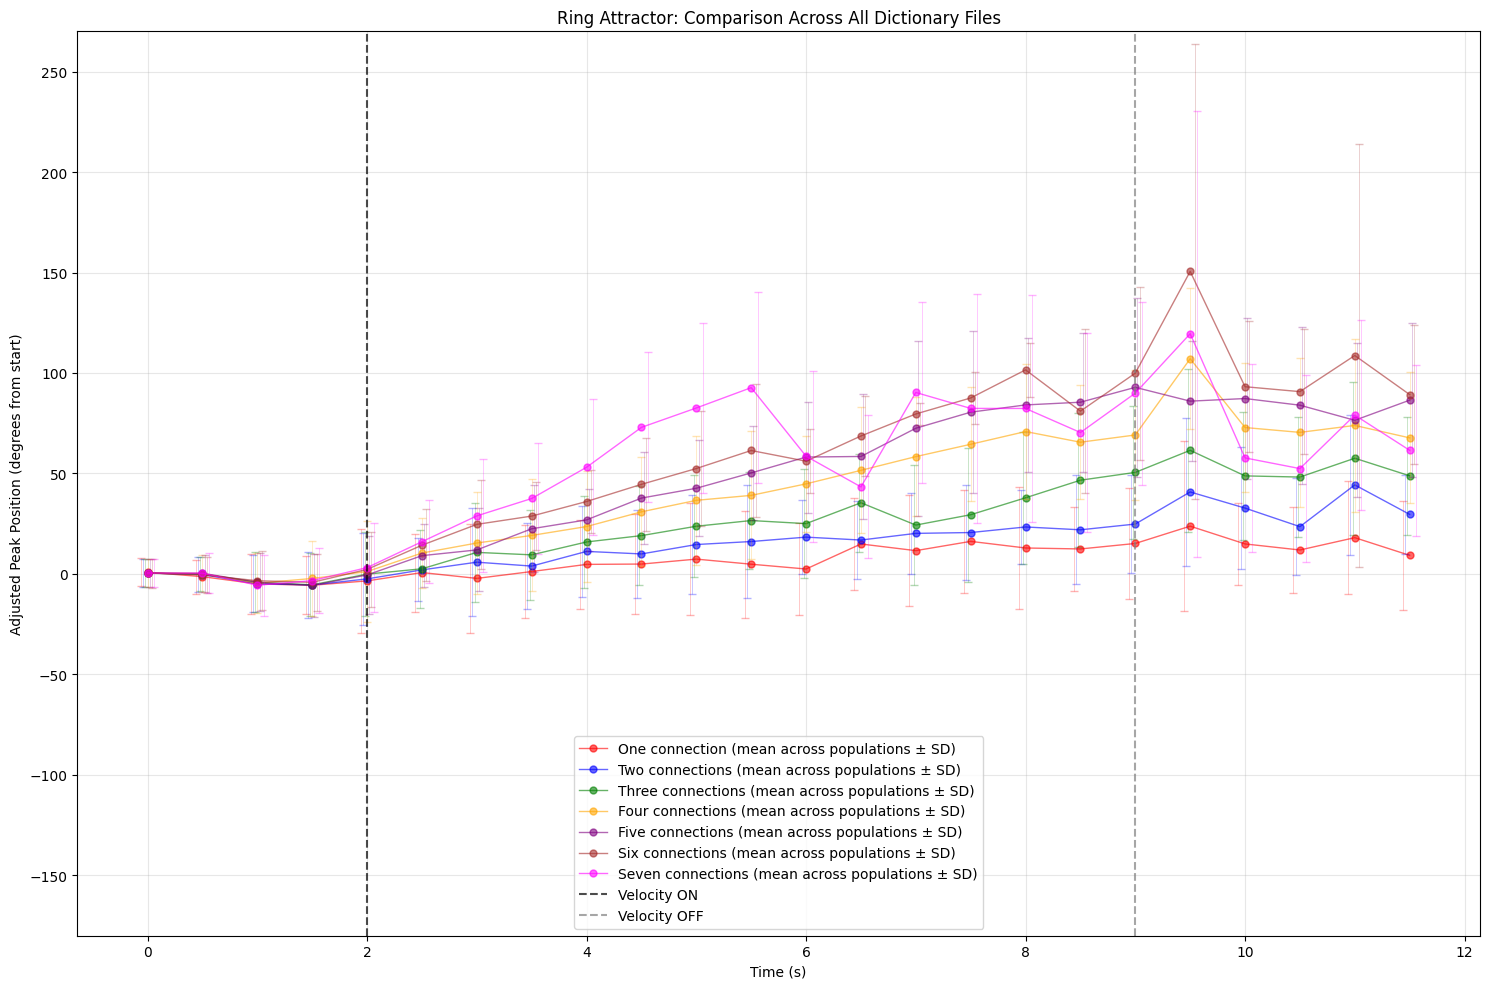

peak_population_dic_velocity_connection_one_connection_per_pop: Mean drift = 7.1°, Mean variability = 23.3°
peak_population_dic_velocity_connection_two_connections_per_pop: Mean drift = 15.4°, Mean variability = 22.0°
peak_population_dic_velocity_connection_three_connections_per_pop: Mean drift = 25.6°, Mean variability = 25.6°
peak_population_dic_velocity_connection_four_connections_per_post_neur: Mean drift = 41.1°, Mean variability = 27.1°
peak_population_dic_velocity_connection_five_connections_per_pop: Mean drift = 47.7°, Mean variability = 27.1°
peak_population_dic_velocity_connection_six_connections_per_pop: Mean drift = 56.8°, Mean variability = 28.7°
peak_population_dic_velocity_connection_seven_connections_per_pop: Mean drift = 52.8°, Mean variability = 38.9°


In [65]:

import os
import numpy as np
import matplotlib.pyplot as plt
from glob import glob

# Find all .npy files containing 'dic' in the filename
npy_files = glob("/Users/flaviadavidhi/Documents/PhD/JointAttractorNets/*dic*.npy")  # or use full path: glob("/path/to/folder/*dic*.npy")
print(f"Found {len(npy_files)} files: {npy_files}")

# Sort files to match with legend labels
def get_number_from_filename(filename):
    if 'one' in filename.lower(): return 1
    elif 'two' in filename.lower(): return 2
    elif 'three' in filename.lower(): return 3
    elif 'four' in filename.lower(): return 4
    elif 'five' in filename.lower(): return 5
    elif 'six' in filename.lower(): return 6
    elif 'seven' in filename.lower(): return 6
    else: return 999  # files without number words go last

npy_files = sorted(npy_files, key=get_number_from_filename)
legend_labels = ["One connection", "Two connections", "Three connections", 
                 "Four connections", "Five connections", "Six connections",
                 "Seven connections"]


# Load all dictionaries and analyze
results = {}
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'magenta', 'gray']

for i, file_path in enumerate(npy_files):
   # Load the dictionary
   peak_dict = np.load(file_path, allow_pickle=True).item()
   file_name = os.path.basename(file_path).replace('.npy', '')
   
   # Your original analysis code for each dictionary
   initial_degrees = {pop: pop * 36 for pop in range(10)}
   adjusted_means = {}
   
   for pop in peak_dict:
       if len(peak_dict[pop]) > 0:
           mean_pos = peak_dict[pop][0]
           initial_deg = initial_degrees[pop]
           diff = mean_pos - initial_deg
           diff = ((diff + 180) % 360) - 180
           adjusted = diff
           adjusted_means[pop] = adjusted
   
   if len(adjusted_means) > 0:
        all_adjusted = np.array(list(adjusted_means.values()))
       
        # Calculate circular distances from circular mean for outlier detection
        circ_mean = np.angle(np.nanmean(np.exp(1j * all_adjusted_rad), axis=0))
        circ_distances = np.abs(np.angle(np.exp(1j * (all_adjusted_rad - circ_mean))))
        
        print("all_adjusted: ", all_adjusted)
        
        # Remove outliers (angles more than 90° from circular mean)
        outlier_threshold = np.deg2rad(90)  # adjust as needed
        mask = circ_distances < outlier_threshold
        all_adjusted_filtered = np.where(mask, all_adjusted, np.nan)
        
        print("all_adjusted_filtered: ", all_adjusted_filtered)

        all_adjusted_rad = np.deg2rad(all_adjusted_filtered)
        population_mean = np.rad2deg(np.angle(np.nanmean(np.exp(1j * all_adjusted_rad), axis=0)))
        population_std = np.rad2deg(np.nanstd(np.angle(np.exp(1j * all_adjusted_rad)), axis=0))
        times = np.arange(len(population_mean)) * timestep
       
        results[file_name] = {
            'times': times,
            'population_mean': population_mean,
            'population_std': population_std,
            'color': colors[i % len(colors)]
        }

# Plot all on one figure
plt.figure(figsize=(15, 10))

# Define small offsets for each line
offset_step = 0.02 # adjust this value to make offsets bigger/smaller
base_offset = -(len(results) - 1) * offset_step / 2  # center the offsets


for i, (name, data) in enumerate(results.items()):
   offset = base_offset + i * offset_step
    
   # Plot line and markers first (solid)
   plt.plot(data['times'], data['population_mean'], 
             marker='o', linewidth=1, markersize=5, color=data['color'], alpha = 0.6,
             label=f'{legend_labels[i]} (mean across populations ± SD)')
    
    
   # Add error bars separately (transparent)
   plt.errorbar(data['times'] + offset, data['population_mean'], yerr=data['population_std'],
               fmt='none', linewidth = 0.5, capsize=3, color=data['color'], alpha=0.3)


# Add phase markers if they exist
try:
   plt.axvline(t1, ls='--', lw=1.5, c='black', alpha=0.7, label='Velocity ON')
   plt.axvline(t1+t2, ls='--', lw=1.5, c='gray', alpha=0.7, label='Velocity OFF')
except:
   pass

plt.xlabel('Time (s)')
plt.ylabel('Adjusted Peak Position (degrees from start)')
plt.title('Ring Attractor: Comparison Across All Dictionary Files')
plt.ylim(-180, 270)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Print summary
for name, data in results.items():
   print(f"{name}: Mean drift = {np.nanmean(data['population_mean']):.1f}°, Mean variability = {np.nanmean(data['population_std']):.1f}°")

Found 7 files: ['/Users/flaviadavidhi/Documents/PhD/JointAttractorNets/peak_population_dic_velocity_connection_one_connection_per_pop.npy', '/Users/flaviadavidhi/Documents/PhD/JointAttractorNets/peak_population_dic_velocity_connection_four_connections_per_post_neur.npy', '/Users/flaviadavidhi/Documents/PhD/JointAttractorNets/peak_population_dic_velocity_connection_five_connections_per_pop.npy', '/Users/flaviadavidhi/Documents/PhD/JointAttractorNets/peak_population_dic_velocity_connection_six_connections_per_pop.npy', '/Users/flaviadavidhi/Documents/PhD/JointAttractorNets/peak_population_dic_velocity_connection_three_connections_per_pop.npy', '/Users/flaviadavidhi/Documents/PhD/JointAttractorNets/peak_population_dic_velocity_connection_two_connections_per_pop.npy', '/Users/flaviadavidhi/Documents/PhD/JointAttractorNets/peak_population_dic_velocity_connection_seven_connections_per_pop.npy']
all_adjusted:  [[ 3.07461466e+00 -6.96845053e+00 -6.96845053e+00 -1.03288049e+01
  -1.92388286e+01

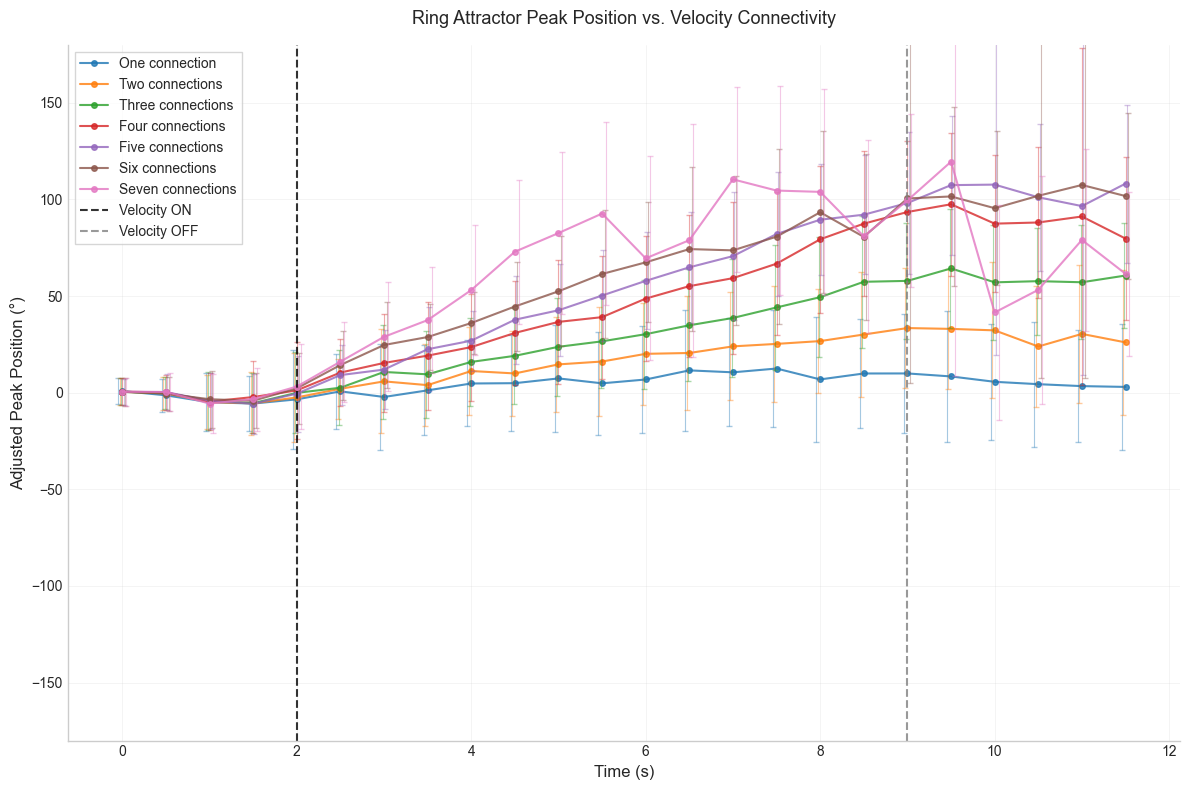

In [76]:
import os
import numpy as np
import matplotlib.pyplot as plt
from glob import glob

# [Keep all your data loading and processing code exactly the same until plotting]

# Plot all on one figure - SCIENTIFIC STYLE
fig, ax = plt.subplots(figsize=(12, 8))


import os
import numpy as np
import matplotlib.pyplot as plt
from glob import glob

# Find all .npy files containing 'dic' in the filename
npy_files = glob("/Users/flaviadavidhi/Documents/PhD/JointAttractorNets/*dic*.npy")  # or use full path: glob("/path/to/folder/*dic*.npy")
print(f"Found {len(npy_files)} files: {npy_files}")

# Sort files to match with legend labels
def get_number_from_filename(filename):
    if 'one' in filename.lower(): return 1
    elif 'two' in filename.lower(): return 2
    elif 'three' in filename.lower(): return 3
    elif 'four' in filename.lower(): return 4
    elif 'five' in filename.lower(): return 5
    elif 'six' in filename.lower(): return 6
    elif 'seven' in filename.lower(): return 6
    else: return 999  # files without number words go last

npy_files = sorted(npy_files, key=get_number_from_filename)
legend_labels = ["One connection", "Two connections", "Three connections", 
                 "Four connections", "Five connections", "Six connections",
                 "Seven connections"]


# Load all dictionaries and analyze
results = {}
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'magenta', 'gray']

for i, file_path in enumerate(npy_files):
   # Load the dictionary
   peak_dict = np.load(file_path, allow_pickle=True).item()
   file_name = os.path.basename(file_path).replace('.npy', '')
   
   # Your original analysis code for each dictionary
   initial_degrees = {pop: pop * 36 for pop in range(10)}
   adjusted_means = {}
   
   for pop in peak_dict:
       if len(peak_dict[pop]) > 0:
           mean_pos = peak_dict[pop][0]
           initial_deg = initial_degrees[pop]
           diff = mean_pos - initial_deg
           diff = ((diff + 180) % 360) - 180
           adjusted = diff
           adjusted_means[pop] = adjusted
   
   if len(adjusted_means) > 0:
        all_adjusted = np.array(list(adjusted_means.values()))

        # Convert to radians FIRST
        all_adjusted_rad = np.deg2rad(all_adjusted)

        # Calculate circular distances from circular mean for outlier detection
        circ_mean = np.angle(np.nanmean(np.exp(1j * all_adjusted_rad), axis=0))
        circ_distances = np.abs(np.angle(np.exp(1j * (all_adjusted_rad - circ_mean))))

        print("all_adjusted: ", all_adjusted)

        # Remove outliers (angles more than 90° from circular mean)
        outlier_threshold = np.deg2rad(90)
        mask = circ_distances < outlier_threshold
        all_adjusted_filtered = np.where(mask, all_adjusted, np.nan)

        print("all_adjusted_filtered: ", all_adjusted_filtered)

        # Convert filtered data to radians for final calculation
        all_adjusted_filtered_rad = np.deg2rad(all_adjusted_filtered)
        population_mean = np.rad2deg(np.angle(np.nanmean(np.exp(1j * all_adjusted_filtered_rad), axis=0)))
        population_std = np.rad2deg(np.nanstd(np.angle(np.exp(1j * all_adjusted_filtered_rad)), axis=0))
        times = np.arange(len(population_mean)) * timestep
       
        results[file_name] = {
            'times': times,
            'population_mean': population_mean,
            'population_std': population_std,
            'color': colors[i % len(colors)]
        }


# Better scientific color palette - colorblind friendly
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']

# Define small offsets for each line
offset_step = 0.015
base_offset = -(len(results) - 1) * offset_step / 2

for i, (name, data) in enumerate(results.items()):
    offset = base_offset + i * offset_step
    
    # Plot line and markers - cleaner style
    ax.plot(data['times'], data['population_mean'], 
            marker='o', linewidth=1.5, markersize=4, 
            color=colors[i % len(colors)], alpha=0.8,
            label=legend_labels[i])  # Simplified labels
    
    # Add error bars separately
    ax.errorbar(data['times'] + offset, data['population_mean'], 
               yerr=data['population_std'],
               fmt='none', linewidth=0.8, capsize=2, 
               color=colors[i % len(colors)], alpha=0.4)

# Add phase markers
try:
    ax.axvline(t1, ls='--', lw=1.5, c='black', alpha=0.8, label='Velocity ON')
    ax.axvline(t1+t2, ls='--', lw=1.5, c='gray', alpha=0.8, label='Velocity OFF')
except:
    pass

# Scientific formatting
ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Adjusted Peak Position (°)', fontsize=12)
ax.set_title('Ring Attractor Peak Position vs. Velocity Connectivity', fontsize=13, pad=15)
ax.set_ylim(-180, 180)

# Clean grid and spines
ax.grid(True, alpha=0.3, linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Better legend for scientific plot
ax.legend(frameon=True, fancybox=False, shadow=False, 
          fontsize=10, loc='best')

plt.tight_layout()
plt.show()

Found 8 files: ['/Users/flaviadavidhi/Documents/PhD/JointAttractorNets/peak_population_dic_velocity_connection_one_connection_per_pop.npy', '/Users/flaviadavidhi/Documents/PhD/JointAttractorNets/peak_population_dic_velocity_connection_four_connections_per_post_neur.npy', '/Users/flaviadavidhi/Documents/PhD/JointAttractorNets/peak_population_dic_velocity_connection_five_connections_per_pop.npy', '/Users/flaviadavidhi/Documents/PhD/JointAttractorNets/peak_population_dic_velocity_connection_six_connections_per_pop.npy', '/Users/flaviadavidhi/Documents/PhD/JointAttractorNets/peak_population_dic_velocity_connection_three_connections_per_pop.npy', '/Users/flaviadavidhi/Documents/PhD/JointAttractorNets/peak_population_dic_velocity_connection_two_connections_per_pop.npy', '/Users/flaviadavidhi/Documents/PhD/JointAttractorNets/peak_population_dic_velocity_connection_eight_connections_per_pop.npy', '/Users/flaviadavidhi/Documents/PhD/JointAttractorNets/peak_population_dic_velocity_connection_sev

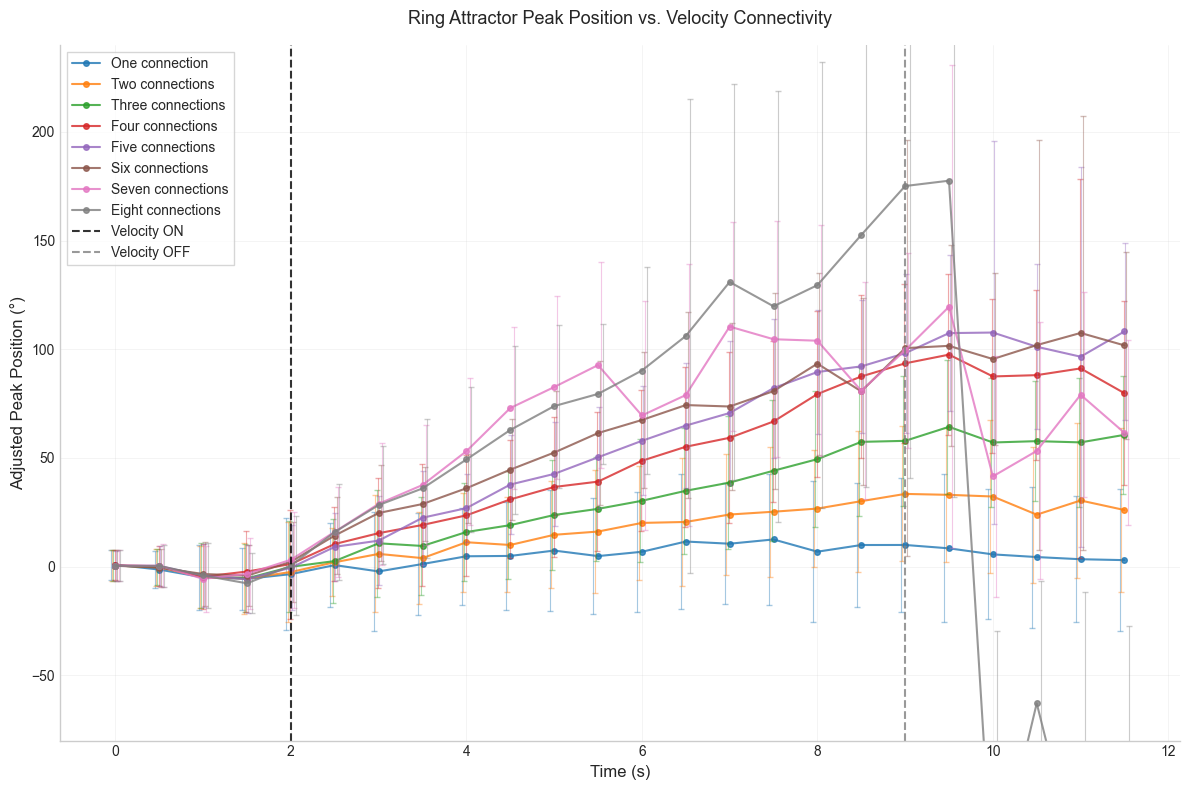

In [87]:
import os
import numpy as np
import matplotlib.pyplot as plt
from glob import glob

# Find all .npy files containing 'dic' in the filename
npy_files = glob("/Users/flaviadavidhi/Documents/PhD/JointAttractorNets/*dic*.npy")
print(f"Found {len(npy_files)} files: {npy_files}")

# Sort files to match with legend labels
def get_number_from_filename(filename):
    if 'one' in filename.lower(): return 1
    elif 'two' in filename.lower(): return 2
    elif 'three' in filename.lower(): return 3
    elif 'four' in filename.lower(): return 4
    elif 'five' in filename.lower(): return 5
    elif 'six' in filename.lower(): return 6
    elif 'seven' in filename.lower(): return 7  # Fixed: was 6
    elif 'eight' in filename.lower(): return 8  # Fixed: was 6
    else: return 999

npy_files = sorted(npy_files, key=get_number_from_filename)
legend_labels = ["One connection", "Two connections", "Three connections", 
                 "Four connections", "Five connections", "Six connections",
                 "Seven connections", "Eight connections"]

# Load all dictionaries and analyze
results = {}
# Better scientific color palette - colorblind friendly (moved here)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']

for i, file_path in enumerate(npy_files):
    # Load the dictionary
    peak_dict = np.load(file_path, allow_pickle=True).item()
    file_name = os.path.basename(file_path).replace('.npy', '')
    
    # Your original analysis code for each dictionary
    initial_degrees = {pop: pop * 36 for pop in range(10)}
    adjusted_means = {}
    
    for pop in peak_dict:
        if len(peak_dict[pop]) > 0:
            mean_pos = peak_dict[pop][0]
            initial_deg = initial_degrees[pop]
            diff = mean_pos - initial_deg
            diff = ((diff + 180) % 360) - 180
            adjusted = diff
            adjusted_means[pop] = adjusted
    
    if len(adjusted_means) > 0:
        all_adjusted = np.array(list(adjusted_means.values()))

        # Convert to radians FIRST
        all_adjusted_rad = np.deg2rad(all_adjusted)

        # Calculate circular distances from circular mean for outlier detection
        circ_mean = np.angle(np.nanmean(np.exp(1j * all_adjusted_rad), axis=0))
        circ_distances = np.abs(np.angle(np.exp(1j * (all_adjusted_rad - circ_mean))))

        # Remove outliers (angles more than 90° from circular mean)
        outlier_threshold = np.deg2rad(90)
        mask = circ_distances < outlier_threshold
        all_adjusted_filtered = np.where(mask, all_adjusted, np.nan)

        # Convert filtered data to radians for final calculation
        all_adjusted_filtered_rad = np.deg2rad(all_adjusted_filtered)
        population_mean = np.rad2deg(np.angle(np.nanmean(np.exp(1j * all_adjusted_filtered_rad), axis=0)))
        population_std = np.rad2deg(np.nanstd(np.angle(np.exp(1j * all_adjusted_filtered_rad)), axis=0))
        times = np.arange(len(population_mean)) * timestep  # Make sure timestep is defined!
        
        results[file_name] = {
            'times': times,
            'population_mean': population_mean,
            'population_std': population_std,
            'color': colors[i % len(colors)]
        }

# Plot all on one figure - SCIENTIFIC STYLE
fig, ax = plt.subplots(figsize=(12, 8))

# Define small offsets for each line
offset_step = 0.015
base_offset = -(len(results) - 1) * offset_step / 2

for i, (name, data) in enumerate(results.items()):
    offset = base_offset + i * offset_step
    
    # Plot line and markers - cleaner style
    ax.plot(data['times'], data['population_mean'], 
            marker='o', linewidth=1.5, markersize=4, 
            color=colors[i % len(colors)], alpha=0.8,
            label=legend_labels[i])
    
    # Add error bars separately
    ax.errorbar(data['times'] + offset, data['population_mean'], 
               yerr=data['population_std'],
               fmt='none', linewidth=0.8, capsize=2, 
               color=colors[i % len(colors)], alpha=0.4)

# Add phase markers
try:
    ax.axvline(t1, ls='--', lw=1.5, c='black', alpha=0.8, label='Velocity ON')
    ax.axvline(t1+t2, ls='--', lw=1.5, c='gray', alpha=0.8, label='Velocity OFF')
except:
    pass

# Scientific formatting
ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Adjusted Peak Position (°)', fontsize=12)
ax.set_title('Ring Attractor Peak Position vs. Velocity Connectivity', fontsize=13, pad=15)
ax.set_ylim(-80, 240)

# Clean grid and spines
ax.grid(True, alpha=0.3, linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Better legend for scientific plot
ax.legend(frameon=True, fancybox=False, shadow=False, 
          fontsize=10, loc='best')

plt.tight_layout()
plt.show()